# MeatLens MobileNetV3Small 12-Fold Processed ROI CNN-Only Notebook

This notebook trains the MeatLens comparison model using:

- MobileNetV3Small only
- 12-fold cross-rotation
- interval-sampled 12-sample splits (8 MeatLens + 4 Public Dataset 2)
- already processed HSV/LAB-threshold segmented ROI images
- neutralized background
- `224x224` RGB inputs
- no handcrafted RGB/HSV/LAB/GLCM feature branch
- dedicated output root: `training_outputs/mobilenetv3small_12fold_processed_roi_cnn_only/`


Strict accuracy and macro F1 remain the primary metrics. Top-2 accuracy, adjacent accuracy, severe error rate, and ordinal error are kept as secondary transition-aware metrics because pork freshness changes gradually.


In [1]:
import importlib
import inspect

import pandas as pd
from IPython.display import Image as DisplayImage, display

import mobilenetv3small_12fold_processed_roi_cnn_only_lib as lib12

lib12 = importlib.reload(lib12)

print("Library source:", lib12.__file__)
print(
    "Function first lines:",
    {
        "train_mobilenetv3small_12fold_cnn_only_model": lib12.train_mobilenetv3small_12fold_cnn_only_model.__code__.co_firstlineno,
        "run_single_12fold_cnn_only_experiment": lib12.run_single_12fold_cnn_only_experiment.__code__.co_firstlineno,
    },
)
print(
    "Function source files:",
    {
        "train_mobilenetv3small_12fold_cnn_only_model": inspect.getsourcefile(lib12.train_mobilenetv3small_12fold_cnn_only_model),
        "run_single_12fold_cnn_only_experiment": inspect.getsourcefile(lib12.run_single_12fold_cnn_only_experiment),
    },
)

sanity_optimizer = lib12.make_optimizer(1e-3)
print("Sanity optimizer type:", type(sanity_optimizer))
print("Sanity optimizer module:", type(sanity_optimizer).__module__)

if inspect.getsourcefile(lib12.run_single_12fold_cnn_only_experiment) != lib12.__file__:
    raise RuntimeError("Notebook is not using the module-backed experiment function.")

if "legacy" not in type(sanity_optimizer).__module__:
    raise RuntimeError("Notebook did not load the DirectML-safe legacy Adam optimizer.")

print("Notebook sanity check passed.")

lib12.ensure_output_dirs()
lib12.print_library_status()


[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
Library source: e:\Thesis Code\mobilenetv3small_12fold_processed_roi_cnn_only_lib.py
Function first lines: {'train_mobilenetv3small_12fold_cnn_only_model': 1947, 'run_single_12fold_cnn_only_experiment': 2048}
Function source files: {'train_mobilenetv3small_12fold_cnn_only_model': 'e:\\Thesis Code\\mobilenetv3small_12fold_processed_roi_cnn_only_lib.py', 'run_single_12fold_cnn_only_experiment': 'e:\\Thesis Code\\mobilenetv3small_12fold_processed_roi_cnn_only_lib.py'}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Sanity optimizer type: <class 'keras.optimizers.legacy.adam.Adam'>
Sanity optimizer module: keras.optimizers.legacy.adam
Notebook sanity check passed.
TF_AVAILABLE = True
SKLEARN_AVAILABLE = True
SKIMAGE_AVAILABLE = True
CV2_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
PROJECT_ROOT = e:\Thes

In [2]:
print("USE_TRAINING_AUGMENTATION =", lib12.USE_TRAINING_AUGMENTATION)


USE_TRAINING_AUGMENTATION = True


In [3]:
split_dfs = lib12.load_all_cross_rotation_splits()
print("Loaded split keys:", sorted(split_dfs.keys()))
resolved_counts = {
    split_key: int(df["image_path_resolved"].notna().sum())
    for split_key, df in split_dfs.items()
}
resolved_counts


Loaded split keys: ['fold10_test', 'fold10_train', 'fold10_val', 'fold11_test', 'fold11_train', 'fold11_val', 'fold12_test', 'fold12_train', 'fold12_val', 'fold1_test', 'fold1_train', 'fold1_val', 'fold2_test', 'fold2_train', 'fold2_val', 'fold3_test', 'fold3_train', 'fold3_val', 'fold4_test', 'fold4_train', 'fold4_val', 'fold5_test', 'fold5_train', 'fold5_val', 'fold6_test', 'fold6_train', 'fold6_val', 'fold7_test', 'fold7_train', 'fold7_val', 'fold8_test', 'fold8_train', 'fold8_val', 'fold9_test', 'fold9_train', 'fold9_val']


{'fold1_train': 5233,
 'fold1_val': 922,
 'fold1_test': 600,
 'fold2_train': 5234,
 'fold2_val': 923,
 'fold2_test': 598,
 'fold3_train': 5301,
 'fold3_val': 936,
 'fold3_test': 518,
 'fold4_train': 5275,
 'fold4_val': 931,
 'fold4_test': 549,
 'fold5_train': 5232,
 'fold5_val': 923,
 'fold5_test': 600,
 'fold6_train': 5233,
 'fold6_val': 922,
 'fold6_test': 600,
 'fold7_train': 5277,
 'fold7_val': 931,
 'fold7_test': 547,
 'fold8_train': 5233,
 'fold8_val': 922,
 'fold8_test': 600,
 'fold9_train': 5232,
 'fold9_val': 923,
 'fold9_test': 600,
 'fold10_train': 5232,
 'fold10_val': 923,
 'fold10_test': 600,
 'fold11_train': 5406,
 'fold11_val': 954,
 'fold11_test': 395,
 'fold12_train': 5276,
 'fold12_val': 931,
 'fold12_test': 548}

In [4]:
metadata_validation_df = lib12.validate_metadata_mapping(split_dfs)
metadata_validation_df


,sample_id,sample_number,pork_cut,capture_source,phone_group,rows_found,uses_placeholder_metadata
0,pork_shoulder_sample_1,1,shoulder,researcher_home,old_phone,7200,False
1,pork_belly_sample_10,10,belly,public_dataset_2,public_dataset_2,7200,False
2,various_pork_meat_sample_11,11,various,public_dataset_2,public_dataset_2,4740,False
3,various_pork_meat_sample_12,12,various,public_dataset_2,public_dataset_2,6576,False
4,pork_shoulder_sample_2,2,shoulder,partner_home,old_phone,7176,False
5,pork_belly_sample_3,3,belly,researcher_home,old_phone,6216,False
6,pork_belly_sample_4,4,belly,partner_home,old_phone,6588,False
7,pork_ham_sample_5,5,ham,researcher_home,new_phone,7200,False
8,pork_ham_sample_6,6,ham,partner_home,new_phone,7200,False
9,pork_loin_sample_7,7,loin,researcher_home,new_phone,6564,False


In [5]:
quality_bundle = lib12.build_dataset_quality_summary(split_dfs)
lib12.print_quality_tables(quality_bundle)
quality_bundle["summary_df"].head(40)



[summary_df]
   split_key  rows  missing_image_path_rows  fresh_count  not_fresh_count  spoiled_count  unique_samples
 fold10_test   600                        0          200              200            200               1
fold10_train  5232                        0         1640             1805           1787              11
  fold10_val   923                        0          290              319            314              11
 fold11_test   395                        0          122              131            142               1
fold11_train  5406                        0         1706             1864           1836              11
  fold11_val   954                        0          302              329            323              11
 fold12_test   548                        0          195              193            160               1
fold12_train  5276                        0         1644             1811           1821              11
  fold12_val   931                       

,split_key,rows,missing_image_path_rows,fresh_count,not_fresh_count,spoiled_count,unique_samples
0,fold10_test,600,0,200,200,200,1
1,fold10_train,5232,0,1640,1805,1787,11
2,fold10_val,923,0,290,319,314,11
3,fold11_test,395,0,122,131,142,1
4,fold11_train,5406,0,1706,1864,1836,11
5,fold11_val,954,0,302,329,323,11
6,fold12_test,548,0,195,193,160,1
7,fold12_train,5276,0,1644,1811,1821,11
8,fold12_val,931,0,291,320,320,11
9,fold1_test,600,0,200,200,200,1


In [6]:
shape_audit = lib12.audit_image_shapes(split_dfs)
shape_audit


already_224_count = 6755
non_224_count = 0
unique_images_checked = 6755


{'already_224_count': 6755, 'non_224_count': 0, 'unique_images_checked': 6755}

Saved sample image figure: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_processed_roi_cnn_only\figures\sample_visualization_grid.png


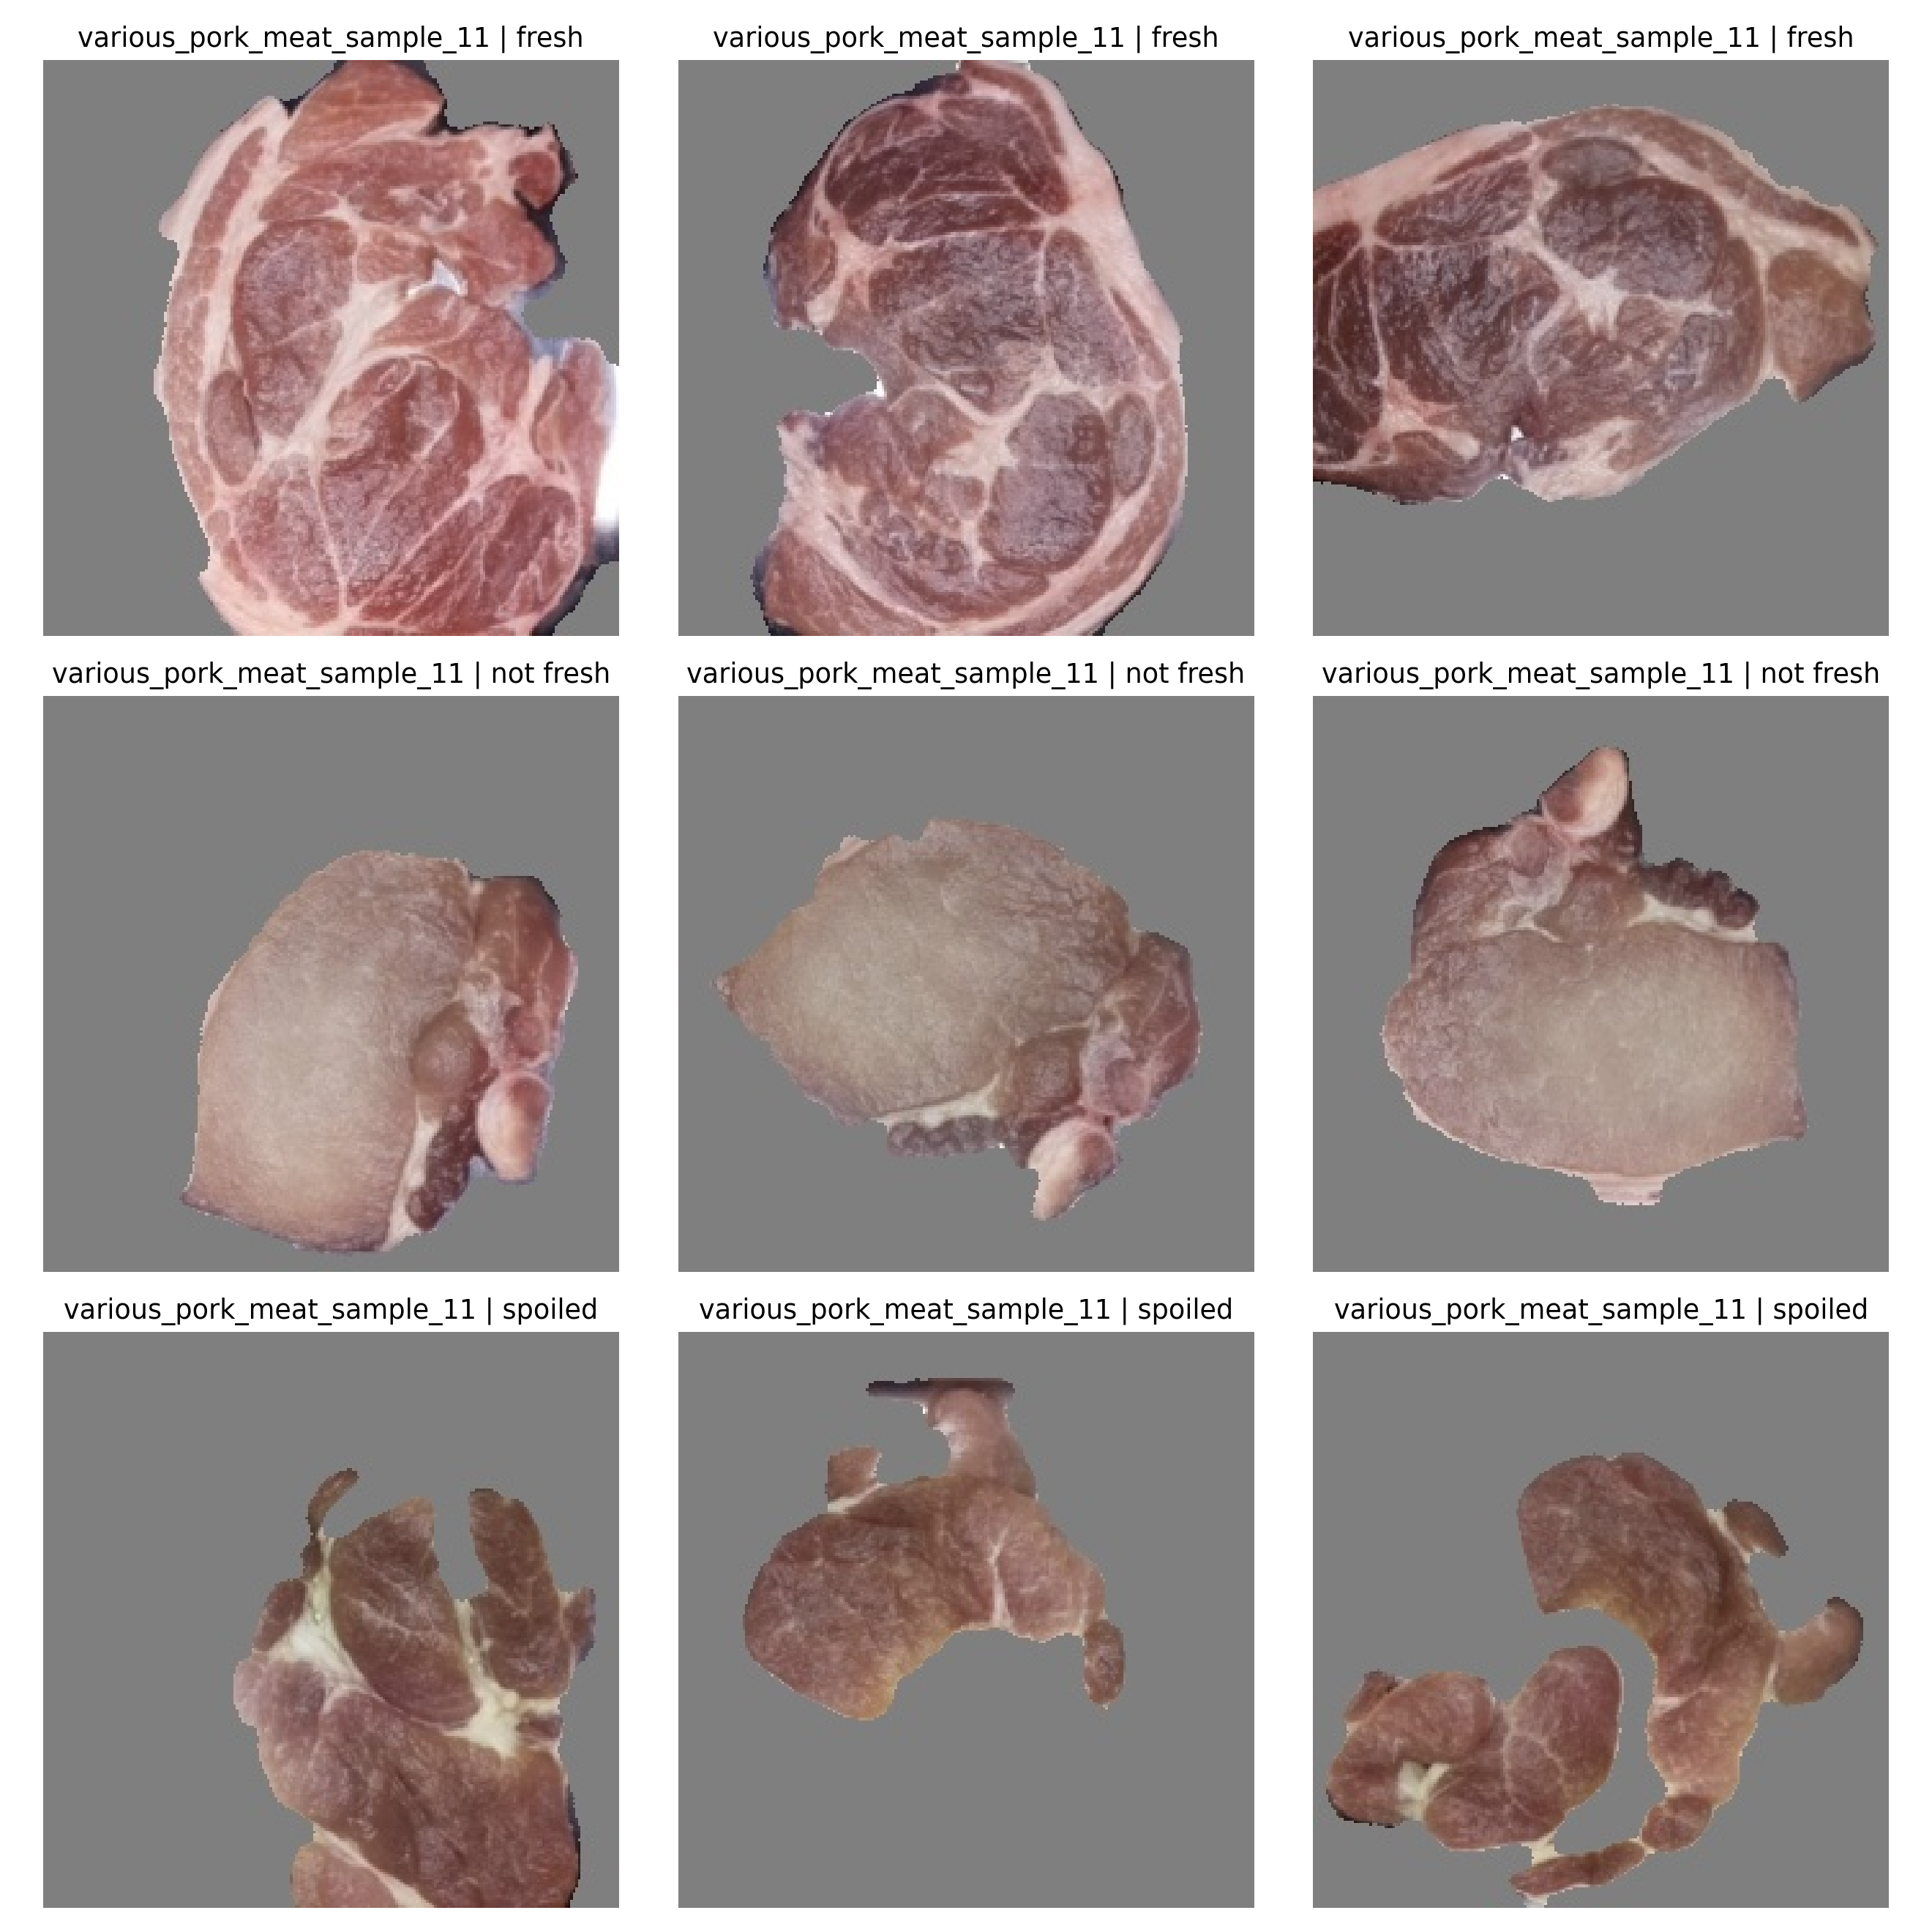

In [7]:
sample_image_figure_path = lib12.save_sample_visualization(split_dfs)
print("Saved sample image figure:", sample_image_figure_path)
display(DisplayImage(filename=str(sample_image_figure_path)))


In [8]:
print("Seed metrics CSV:", lib12.PROCESSED_ROI12_SEED_METRICS_PATH)
print("Split root:", lib12.SPLIT_ROOT)
print("Output root:", lib12.EXTENSION_OUTPUT_ROOT)
print("Comparison CSV path:", lib12.PROCESSED_ROI12_COMPARISON_PATH)


Seed metrics CSV: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_processed_roi_cnn_only\processed_roi12_cnn_only_seed_metrics.csv
Split root: e:\Thesis Code\generated_splits\cross_rotation_interval200_12samples_processed_roi
Output root: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_processed_roi_cnn_only
Comparison CSV path: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_processed_roi_cnn_only\processed_roi12_vs_previous_models_comparison.csv


In [9]:
import inspect

source = inspect.getsource(lib12.train_mobilenetv3small_12fold_cnn_only_model)

print("Contains ModelCheckpoint?", "ModelCheckpoint" in source)
print("Contains load_weights?", "load_weights" in source)
print("Contains .weights.h5?", ".weights.h5" in source)
print("Contains feature_input?", "feature_input" in source)
print("Contains Concatenate?", "Concatenate" in source)
print("Contains StandardScaler?", "StandardScaler" in source)
print("Contains graycomatrix?", "graycomatrix" in source)
print("Contains rgb/hsv/lab/glcm feature extraction?", any(word in source for word in ["glcm", "lab_", "hsv_", "rgb_"]))

print("EXTENSION_FOLDS length:", len(lib12.EXTENSION_FOLDS))
print("SPLIT_ROOT contains expected folder?", "cross_rotation_interval200_12samples_processed_roi" in str(lib12.SPLIT_ROOT))
print("IMAGE_CROP_MODE =", lib12.IMAGE_CROP_MODE)
print("MODEL_INPUT_MODE =", lib12.MODEL_INPUT_MODE)


Contains ModelCheckpoint? False
Contains load_weights? False
Contains .weights.h5? False
Contains feature_input? False
Contains Concatenate? False
Contains StandardScaler? False
Contains graycomatrix? False
Contains rgb/hsv/lab/glcm feature extraction? False
EXTENSION_FOLDS length: 12
SPLIT_ROOT contains expected folder? True
IMAGE_CROP_MODE = preprocessed_hsv_lab_threshold_roi_224
MODEL_INPUT_MODE = cnn_only


## Optional Comparison

If older result CSVs exist, this section compares:

- segmented 6-fold hybrid
- segmented 6-fold CNN-only
- 8-fold processed ROI CNN-only
- current 12-fold processed ROI CNN-only


In [10]:
comparison_bundle = lib12.create_processed_roi12_vs_previous_models_comparison()
if comparison_bundle is not None:
    comparison_bundle["comparison_df"]


[WARN] Missing old result file: e:\Thesis Code\training_outputs\mobilenetv3small_12fold_processed_roi_cnn_only\processed_roi12_cnn_only_seed_metrics.csv


In [ ]:
# debug_result = lib12.run_single_12fold_cnn_only_experiment(
#     fold_name="fold1",
#     seed=42,
# )


: 

## Manual Full Training Cell


In [ ]:
MANUAL_CONFIRM_RUN_FULL_TRAINING = True

if MANUAL_CONFIRM_RUN_FULL_TRAINING:
    RUN_EXTENSION_TRAINING = True
    lib12.RUN_EXTENSION_TRAINING = RUN_EXTENSION_TRAINING
    all_results = lib12.run_12fold_cnn_only_training()
else:
    print("12-fold processed ROI CNN-only training is ready but not started.")
    print("Set MANUAL_CONFIRM_RUN_FULL_TRAINING = True to train.")


Running processed ROI 8-fold CNN-only experiment: fold1 seed=42
train_uint8 shape=(5233, 224, 224, 3), approx_mb=751.22
val_images shape=(922, 224, 224, 3), approx_mb=529.43
test_images shape=(600, 224, 224, 3), approx_mb=344.53
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
[INFO] Compiled optimizer: keras.optimizers.legacy.adam.Adam
Epoch 1/8
 - val_f1_macro: 0.7704
164/164 - 13s - loss: 0.9624 - accuracy: 0.5624 - val_loss: 0.5882 - val_accuracy: 0.7690 - val_f1_macro: 0.7704 - lr: 5.0000e-04 - 13s/epoch - 82ms/step
Epoch 2/8
 - val_f1_macro: 0.8184
164/164 - 6s - loss: 0.6308 - accuracy: 0.7239 - val_loss: 0.4597 - val_accuracy: 0.8178 - val_f1_macro: 0.8184 - lr: 5.0000e-04 - 6s/epoch - 36ms/step
Epoch 3/8
 - val_f1_macro: 0.8280
164/164 - 6s - loss: 0.5425 - accuracy: 0.7678 - val_loss: 0.4061 - val_accuracy: 0.8286 - val_f1_macro: 0.8280 - lr: 5.0000e-04 - 6s/epoch - 35ms/step
Epoch 4/8
 - val_f1_macro: 0.8454
164/164 - 6s - loss: 0.4721 - accuracy: 0.7

## Manual Summary Regeneration Cell


In [ ]:
MANUAL_CONFIRM_REGENERATE_SUMMARIES = False

if MANUAL_CONFIRM_REGENERATE_SUMMARIES:
    regenerate_bundle = lib12.regenerate_metrics_summaries_and_graphs()
else:
    print("Summary regeneration is ready but not started.")


Summary regeneration is ready but not started.


## Completion Check


In [ ]:
expected_runs = [(fold, seed) for fold in lib12.EXTENSION_FOLDS for seed in lib12.EXTENSION_RUN_SEEDS]
print("Expected run count:", len(expected_runs))

completed_runs = set()
if lib12.PROCESSED_ROI12_SEED_METRICS_PATH.exists():
    seed_metrics_df = pd.read_csv(lib12.PROCESSED_ROI12_SEED_METRICS_PATH)
    completed_runs = set(zip(seed_metrics_df["fold_name"].astype(str), seed_metrics_df["seed"].astype(int)))
    print("Completed run count:", len(completed_runs))
else:
    print("Completed run count: 0")

missing_runs = [run for run in expected_runs if run not in completed_runs]
print("Missing runs:", missing_runs)

if lib12.PROCESSED_ROI12_FAILED_RUNS_PATH.exists():
    failed_runs_df = pd.read_csv(lib12.PROCESSED_ROI12_FAILED_RUNS_PATH)
    print("Failed runs:")
    display(failed_runs_df)
else:
    print("Failed runs: none logged")


Expected run count: 36
Completed run count: 0
Missing runs: [('fold1', 42), ('fold1', 123), ('fold1', 2026), ('fold2', 42), ('fold2', 123), ('fold2', 2026), ('fold3', 42), ('fold3', 123), ('fold3', 2026), ('fold4', 42), ('fold4', 123), ('fold4', 2026), ('fold5', 42), ('fold5', 123), ('fold5', 2026), ('fold6', 42), ('fold6', 123), ('fold6', 2026), ('fold7', 42), ('fold7', 123), ('fold7', 2026), ('fold8', 42), ('fold8', 123), ('fold8', 2026), ('fold9', 42), ('fold9', 123), ('fold9', 2026), ('fold10', 42), ('fold10', 123), ('fold10', 2026), ('fold11', 42), ('fold11', 123), ('fold11', 2026), ('fold12', 42), ('fold12', 123), ('fold12', 2026)]
Failed runs: none logged


This notebook trains a CNN-only MobileNetV3Small model using the 12-sample processed segmented ROI dataset (8 MeatLens samples + 4 Public Dataset 2 samples). The input images are already segmented and resized to 224x224, so the notebook does not perform segmentation or handcrafted feature extraction during training. Strict accuracy and macro F1 are the primary metrics, while top-2 accuracy, adjacent accuracy, severe error rate, and ordinal error are reported as secondary transition-aware metrics because pork freshness is a gradual process. This model is intended for comparison against earlier 8-fold processed ROI, hybrid, and segmented CNN-only experiments.
